# 3 - FM Demod

Dieses Notebook liest das gespeicherte FM-IQ-Signal ein und demoduliert es mit einem einfachen IQ-Diskriminator auf Basis der Phasendifferenz benachbarter Samples.

## Prinzip der einfachen FM-Demodulation (IQ)

Für ein komplexes Signal $z[n] = I[n] + jQ[n]$ gilt ein robuster Standardansatz:

$$d[n] = z[n]\,z^*[n-1]$$
$$\Delta\varphi[n] = \angle\{d[n]\}$$
$$f_{demod}[n] \propto \Delta\varphi[n]$$

Äquivalente (nicht normalisierte) Form in I/Q:

$$y[n] = I[n-1]Q[n] - Q[n-1]I[n]$$

Danach folgt ein einfacher Tiefpass (hier: Sliding-Averager), um das Nutzsignal zu glätten.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Audio, display

In [2]:
# 1) Signal laden
in_name = 'FM-IQ-carrier.npy'
in_path = Path.cwd() / in_name
meta_path = Path.cwd() / 'FM-IQ-carrier-meta.npy'

z = np.load(in_path)
meta = np.load(meta_path, allow_pickle=True).item() if meta_path.exists() else {}

fs = float(meta.get('fs_hz', 48_000.0))
f_m = float(meta.get('f_m_hz', 1_000.0))
f_carrier_eff = float(meta.get('f_out_center_hz', meta.get('f_lo_hz', np.nan)))
eta = float(meta.get('eta', np.nan))

if not np.iscomplexobj(z):
    z = z.astype(np.float64) + 1j*np.zeros_like(z, dtype=np.float64)

N = len(z)
t = np.arange(N) / fs
n_plot = min(N, int(6e-3 * fs))

print(f'IQ geladen: {in_path}')
print(f'Samples: {N}, fs = {fs:.1f} Hz, f_m(meta) = {f_m:.1f} Hz, f_carrier_eff(meta) = {f_carrier_eff:.1f} Hz, eta(meta) = {eta:.3f}')

IQ geladen: C:\Users\ralfk\GIT_KT\KT-course\lab_suite\labs\04_03_LABOR-5\submissions\FM-IQ-carrier.npy
Samples: 200000, fs = 200000.0 Hz, f_m(meta) = 880.0 Hz, f_carrier_eff(meta) = -22000.0 Hz, eta(meta) = 1.136


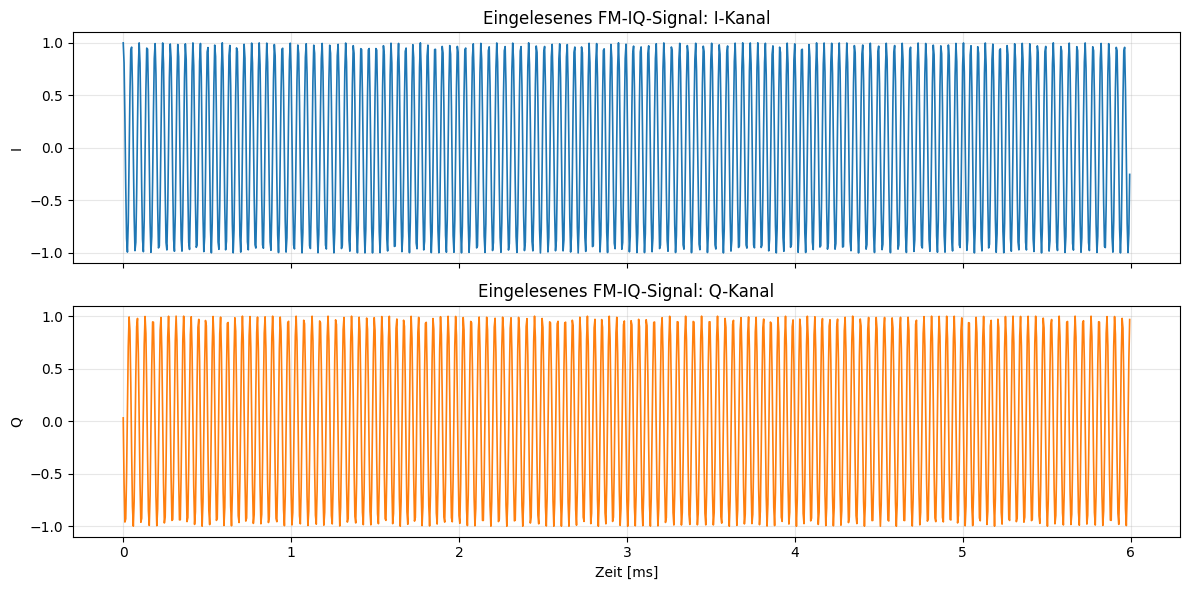

In [3]:
# Plot: Eingelesenes komplexes FM-Signal (I/Q)
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t[:n_plot]*1e3, np.real(z[:n_plot]), lw=1.2)
ax[0].set_title('Eingelesenes FM-IQ-Signal: I-Kanal')
ax[0].set_ylabel('I')
ax[0].grid(alpha=0.3)

ax[1].plot(t[:n_plot]*1e3, np.imag(z[:n_plot]), lw=1.2, color='tab:orange')
ax[1].set_title('Eingelesenes FM-IQ-Signal: Q-Kanal')
ax[1].set_xlabel('Zeit [ms]')
ax[1].set_ylabel('Q')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Plausibilitätscheck: zweiseitiges Spektrum des eingelesenen I/Q-Signals

Zur Kontrolle der Signalqualität wird das zweiseitige Spektrum des komplexen Eingangssignals dargestellt.

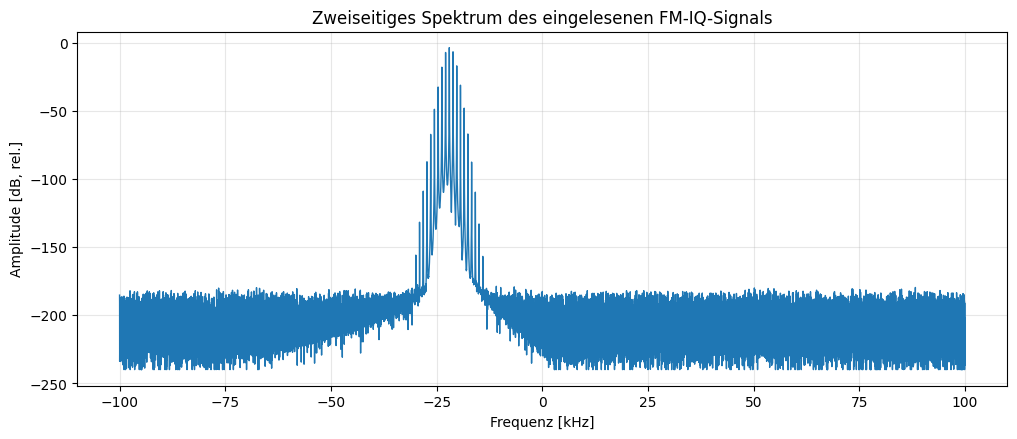

In [4]:
# Zweiseitiges Spektrum des eingelesenen komplexen Signals z
N_fft_spec = 16384
USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'  # 'hann' | 'hamming' | 'rect'

x = np.zeros(N_fft_spec, dtype=np.complex128)
n_copy = min(len(z), N_fft_spec)
x[:n_copy] = z[:n_copy]

if USE_FFT_WINDOW:
    if FFT_WINDOW_KIND == 'hann':
        w = np.hanning(N_fft_spec)
    elif FFT_WINDOW_KIND == 'hamming':
        w = np.hamming(N_fft_spec)
    else:
        w = np.ones(N_fft_spec)
else:
    w = np.ones(N_fft_spec)

cg = np.mean(w)
X = np.fft.fftshift(np.fft.fft(x * w, n=N_fft_spec))
f = np.fft.fftshift(np.fft.fftfreq(N_fft_spec, d=1/fs))
A = np.abs(X) / max(N_fft_spec * cg, 1e-12)
A_db = 20*np.log10(np.maximum(A, 1e-12))

plt.figure(figsize=(12, 4.6))
plt.plot(f/1e3, A_db, lw=1.0)
plt.title('Zweiseitiges Spektrum des eingelesenen FM-IQ-Signals')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [dB, rel.]')
plt.grid(alpha=0.3)
plt.show()

## FM Demodulation

In [5]:
# 2) FM-Demodulation via Phasendifferenz d[n] = z[n] * conj(z[n-1])
d = z[1:] * np.conj(z[:-1])
fm_disc = np.angle(d)

# Auf Originallänge auffüllen (ein Sample Verzögerung)
fm_disc = np.concatenate(([0.0], fm_disc))

# Alternative Vergleichsform (nur zu Demonstrationszwecken)
I = np.real(z)
Q = np.imag(z)
alt = np.zeros_like(I)
alt[1:] = I[:-1]*Q[1:] - Q[:-1]*I[1:]

corr = np.corrcoef(fm_disc[1:], alt[1:])[0, 1] if len(fm_disc) > 2 else np.nan
print(f'Korrelation Phasendifferenz vs. I/Q-Kreuzprodukt: {corr:.4f}')

Korrelation Phasendifferenz vs. I/Q-Kreuzprodukt: 1.0000


In [6]:
# 2a) Tiefpass (Sliding-Averager) und DC-Entfernung
# Grobe, didaktische Wahl: Fenster aus f_m ableiten
f_lp = max(1.5 * f_m, 300.0)
N_win = max(3, int(np.round(fs / f_lp)))
if N_win % 2 == 0:
    N_win += 1

h = np.ones(N_win) / N_win
u_demod = np.convolve(fm_disc, h, mode='same')
u_demod = u_demod - np.mean(u_demod)

print(f'Tiefpass: f_lp ~ {f_lp:.1f} Hz, Fensterbreite N_win = {N_win}')

Tiefpass: f_lp ~ 1320.0 Hz, Fensterbreite N_win = 153


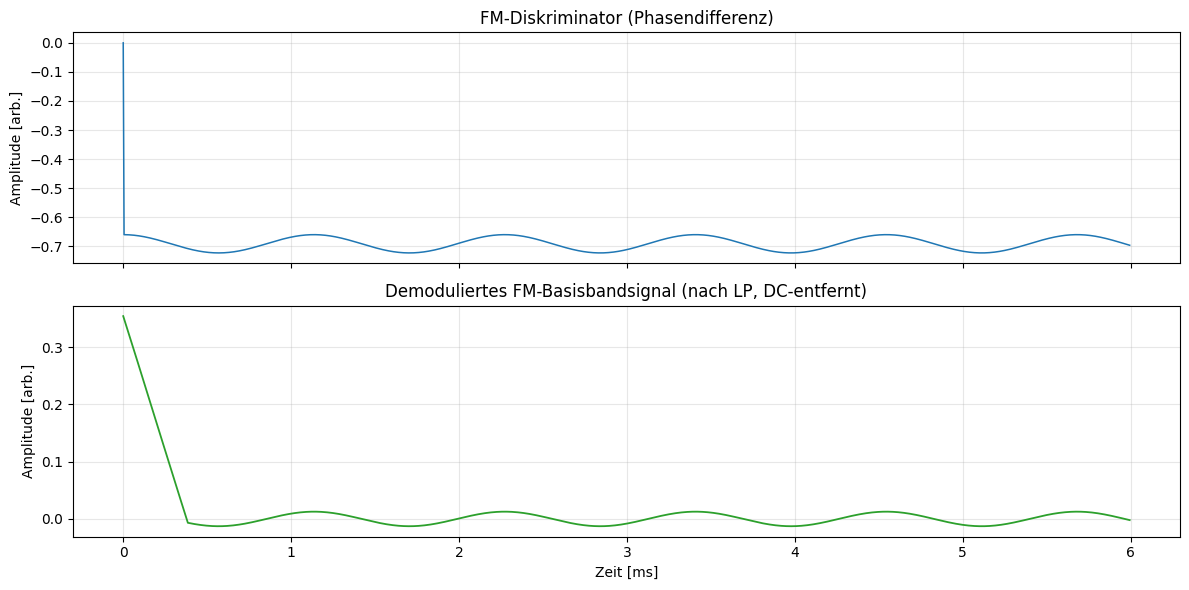

In [7]:
# Plot: Diskriminator-Ausgang und demoduliertes Signal
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t[:n_plot]*1e3, fm_disc[:n_plot], lw=1.1)
ax[0].set_title('FM-Diskriminator (Phasendifferenz)')
ax[0].set_ylabel('Amplitude [arb.]')
ax[0].grid(alpha=0.3)

ax[1].plot(t[:n_plot]*1e3, u_demod[:n_plot], lw=1.3, color='tab:green')
ax[1].set_title('Demoduliertes FM-Basisbandsignal (nach LP, DC-entfernt)')
ax[1].set_xlabel('Zeit [ms]')
ax[1].set_ylabel('Amplitude [arb.]')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Audioausgabe im Notebook

Das demodulierte Signal wird auf 48 kHz resampelt, normiert und zyklisch für einige Sekunden abgespielt.

In [8]:
# Audio-Parameter (für Studenten leicht anpassbar)
fs_audio = 48_000
start_s = 0      # Wiedergabestart [s]
duration_s = 5   # Wiedergabedauer [s]

In [9]:
# 3) Audio vorbereiten und inline abspielen (48 kS/s)
# verwendet fs_audio, start_s, duration_s aus der vorherigen Parameterzelle


# einfache lineare Resampling-Näherung ohne Zusatzbibliothek
duration = len(u_demod) / fs
n_audio = int(duration * fs_audio)
t_src = np.arange(len(u_demod)) / fs
t_dst = np.arange(n_audio) / fs_audio
x_audio = np.interp(t_dst, t_src, u_demod)

# DC entfernen + normieren
x_audio = x_audio - np.mean(x_audio)
x_audio = x_audio / max(np.max(np.abs(x_audio)), 1e-12)

# zyklisch wiederholen, damit mehrere Sekunden hörbar sind
#duration_s = 4.0
rep = max(1, int(np.ceil((duration_s * fs_audio) / len(x_audio))))
#rep = 4
x_audio_rep = np.tile(x_audio, rep)
x_audio_rep = x_audio_rep[:int(duration_s * fs_audio)]

print(f'Audio vorbereitet: samples read: {len(u_demod)} Originaldauer {duration_s} sec x_audio_len={len(x_audio)} rep={rep} len(x_audio_rep)={len(x_audio_rep)} Samples @ {fs_audio} Hz, Dauer {len(x_audio_rep)/fs_audio:.2f} s')
display(Audio(x_audio_rep, rate=fs_audio))

Audio vorbereitet: samples read: 200000 Originaldauer 5 sec x_audio_len=48000 rep=5 len(x_audio_rep)=240000 Samples @ 48000 Hz, Dauer 5.00 s
